<a href="https://www.kaggle.com/code/aamir28/pokemon-stats-types-a-fabricated-mega-block?scriptVersionId=351729533" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 42%, #d33d3d 75%, #f2c94c 100%);
    padding: 40px 36px;
    border-radius: 14px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    text-align: left;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 3px;
    text-transform: uppercase;
">1,351 Pokemon &middot; Base Stats &amp; Forms &middot; EDA Notebook</span>
<h1 style="
    color:#ffffff;
    font-size: 34px;
    font-weight: 800;
    margin: 12px 0 10px 0;
    letter-spacing: -0.5px;
">Pokemon Stats, Types &amp; a Fabricated Mega Block</h1>
<p style="
    color: rgba(255,255,255,0.9);
    font-size: 16px;
    max-width: 640px;
    margin: 0 0 18px 0;
    line-height: 1.5;
">
An exploratory look at base stats, typing, and legendary status across nine generations &mdash; including 49 rows that turn out to be invented Mega Evolutions for Pokemon that have never had one in any real game.
</p>
<div style="display:flex; gap:28px; margin-top:10px;">
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">1,351</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Rows</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">49</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Fabricated Rows</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">614.8</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Legendary Avg. Stats</div>
  </div>
</div>
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 01</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Setup &amp; Data Load</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Import libraries and load the CSV.</p>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'

# Theme colors matching the dataset's banner (charcoal -> poke ball red -> electric yellow)
CHARCOAL, CRIMSON, POKERED, GOLD, STEEL = '#231f20', '#8a1f2b', '#d33d3d', '#f2c94c', '#3d6b8a'

df = pd.read_csv('/kaggle/input/datasets/shreyashautomation/pokemon-stats-dataset/pokemon_complete_stats.csv')
df.shape

(1351, 20)

<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 02</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Data Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check structure, types, and missingness before doing anything else.</p>
</div>


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1351 non-null   int64  
 1   name             1351 non-null   object 
 2   height_dm        1351 non-null   int64  
 3   weight_hg        1351 non-null   int64  
 4   base_experience  1302 non-null   float64
 5   type_1           1351 non-null   object 
 6   type_2           765 non-null    object 
 7   hp               1351 non-null   int64  
 8   attack           1351 non-null   int64  
 9   defense          1351 non-null   int64  
 10  special_attack   1351 non-null   int64  
 11  special_defense  1351 non-null   int64  
 12  speed            1351 non-null   int64  
 13  abilities        1337 non-null   object 
 14  generation       1351 non-null   object 
 15  is_legendary     1351 non-null   bool   
 16  is_mythical      1351 non-null   bool   
 17  color         

<div style="
    border-left: 4px solid #3d6b8a;
    background: #eef3f6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17202a;
">
<b style="color:#3d6b8a; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The dataset loads as a single flat table: <b>1,351 rows &times; 20 columns</b>. Each row is one Pokemon entry &mdash; a base species, a regional variant, or a special battle form (Mega, Gigantamax, and others) &mdash; with base stats, typing, physical measurements, and legendary/mythical flags.
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 03</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Missingness</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Quantify which columns have gaps and check what a gap actually means for each one.</p>
</div>


In [3]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

type_2             586
base_experience     49
abilities           14
dtype: int64

<div style="
    border-left: 4px solid #3d6b8a;
    background: #eef3f6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17202a;
">
<b style="color:#3d6b8a; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<code>type_2</code> is missing for <b>586 rows (43.4%)</b> &mdash; and here, missing isn't a data gap at all: it means the Pokemon genuinely has only one type. <code>base_experience</code> (49 rows) and <code>abilities</code> (14 rows) are smaller, genuine gaps, checked directly in the next two sections rather than assumed.
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 04</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Duplicates &amp; Label Consistency</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Confirm every row is a distinct entry and categorical fields are clean.</p>
</div>


In [4]:
print(f"Duplicate ids: {df['id'].duplicated().sum()}")
print(f"Duplicate names: {df['name'].duplicated().sum()}")
print(f"Full duplicate rows: {df.duplicated().sum()}")

Duplicate ids: 0
Duplicate names: 0
Full duplicate rows: 0


<div style="
    border-left: 4px solid #3d6b8a;
    background: #eef3f6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17202a;
">
<b style="color:#3d6b8a; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Zero duplicates on id, name, or full rows. Categorical columns (<code>type_1</code>, <code>type_2</code>, <code>color</code>, <code>shape</code>, <code>generation</code>) show no case or whitespace inconsistencies on inspection either.
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 05</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Investigating the base_experience Gap</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">All 49 missing values cluster somewhere specific. Find out where before treating them as routine.</p>
</div>


In [5]:
missing_bx = df[df['base_experience'].isna()]
print(f"Rows missing base_experience: {len(missing_bx)}")
print(f"All of them end in '-mega': {missing_bx['name'].str.contains('-mega').all()}")
print(f"Id range of these rows: {missing_bx['id'].min()} - {missing_bx['id'].max()}")
missing_bx[['id', 'name', 'is_legendary', 'is_mythical']].head(10)

Rows missing base_experience: 49
All of them end in '-mega': True
Id range of these rows: 10278 - 10326


,id,name,is_legendary,is_mythical
1302,10278,clefable-mega,False,False
1303,10279,victreebel-mega,False,False
1304,10280,starmie-mega,False,False
1305,10281,dragonite-mega,False,False
1306,10282,meganium-mega,False,False
1307,10283,feraligatr-mega,False,False
1308,10284,skarmory-mega,False,False
1309,10285,froslass-mega,False,False
1310,10286,emboar-mega,False,False
1311,10287,excadrill-mega,False,False


<div style="
    border-left: 4px solid #d33d3d;
    background: #fbeaea;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #2a1414;
">
<b style="color:#8a1f2b; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Data Quality Flag</b><br>
Every single row with a missing <code>base_experience</code> has a name ending in <code>-mega</code>, and all 49 sit in one tight id block (10278&ndash;10326). That's an unusual enough pattern to check further &mdash; the next section looks at these 49 rows by name, not just by id.
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 06</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">These Are Not Real Mega Evolutions</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Compare this block against the actual list of Mega Evolutions from the games.</p>
</div>


In [6]:
real_megas = df[(df['id'] >= 10033) & (df['id'] <= 10090)]
fake_megas = df[(df['id'] >= 10278) & (df['id'] <= 10326)]

print(f"Real Mega block: {len(real_megas)} rows, ids {real_megas['id'].min()}-{real_megas['id'].max()}, 0 gaps")
print(f"Real examples: {real_megas['name'].head(6).tolist()}")
print()
print(f"Second block: {len(fake_megas)} rows, ids {fake_megas['id'].min()}-{fake_megas['id'].max()}")
print(f"Contains: {fake_megas['name'].head(10).tolist()}")
print()
mythical_fakes = fake_megas[fake_megas['is_mythical']]
print(f"Mythical Pokemon in this block: {mythical_fakes['name'].tolist()}")

Real Mega block: 58 rows, ids 10033-10090, 0 gaps
Real examples: ['venusaur-mega', 'charizard-mega-x', 'charizard-mega-y', 'blastoise-mega', 'alakazam-mega', 'gengar-mega']

Second block: 49 rows, ids 10278-10326
Contains: ['clefable-mega', 'victreebel-mega', 'starmie-mega', 'dragonite-mega', 'meganium-mega', 'feraligatr-mega', 'skarmory-mega', 'froslass-mega', 'emboar-mega', 'excadrill-mega']

Mythical Pokemon in this block: ['darkrai-mega', 'magearna-mega', 'magearna-original-mega', 'zeraora-mega']


<div style="
    border-left: 4px solid #d33d3d;
    background: #fbeaea;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #2a1414;
">
<b style="color:#8a1f2b; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Data Quality Flag</b><br>
The first block (ids 10033&ndash;10090, 58 rows, no gaps) is the real, complete list of Mega Evolutions from the actual games: Venusaur, Charizard X/Y, Blastoise, Mewtwo X/Y, Rayquaza, and so on. The second block (ids 10278&ndash;10326, 49 rows) invents Mega forms for Pokemon that have <b>never</b> had one in any real game &mdash; Clefable, Victreebel, Starmie, Dragonite, Meganium, Skarmory, Chandelure, Golurk, Baxcalibur, and more, plus an invented <code>-mega-z</code> tier alongside the real <code>-mega-x</code>/<code>-mega-y</code> naming used only for Charizard and Mewtwo. Most tellingly: this block includes <b>Darkrai, Magearna (both forms), and Zeraora</b> &mdash; Mythical Pokemon, a category that by game design never receives Mega Evolutions at all. These 49 rows are excluded from every section that follows.
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 07</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Excluding the Fabricated Rows</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Build the working table used for the rest of this notebook.</p>
</div>


In [7]:
FAKE_MEGA_IDS = set(range(10278, 10327))
clean = df[~df['id'].isin(FAKE_MEGA_IDS)].copy()
clean['total_stats'] = clean[['hp', 'attack', 'defense', 'special_attack', 'special_defense', 'speed']].sum(axis=1)
print(f"Working table: {len(clean)} rows ({len(df) - len(clean)} excluded)")

Working table: 1302 rows (49 excluded)


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 08</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Real Oddities That Aren't Errors</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check the dataset's most extreme height and weight values — genuine game quirks, not data problems.</p>
</div>


In [8]:
print(clean.nlargest(3, 'height_dm')[['name', 'height_dm', 'weight_hg']])
print()
print(clean.nlargest(5, 'weight_hg')[['name', 'height_dm', 'weight_hg']])

                     name  height_dm  weight_hg
1214  eternatus-eternamax       1000          0
1244     centiskorch-gmax        750      10000
1249       duraludon-gmax        430      10000

                 name  height_dm  weight_hg
1219    venusaur-gmax        240      10000
1220   charizard-gmax        280      10000
1221   blastoise-gmax        250      10000
1222  butterfree-gmax        170      10000
1223     pikachu-gmax        210      10000


<div style="
    border-left: 4px solid #3d6b8a;
    background: #eef3f6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17202a;
">
<b style="color:#3d6b8a; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>Eternatus-eternamax</b> at height_dm=1000 (100 meters) is a real, canonical in-game form. Every <b>Gigantamax</b> row shows an identical weight_hg of 10,000 (1,000 kg) &mdash; not a copy-paste error, but a well-documented real quirk: Gigantamax Pokemon have no officially defined in-game weight, so this exact placeholder value is used uniformly across all of them. Unlike Section 06, these are genuine facts about the source games, correctly represented here.
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 09</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Type Distribution</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">How the 18 primary types are represented, and how common dual-typing is.</p>
</div>


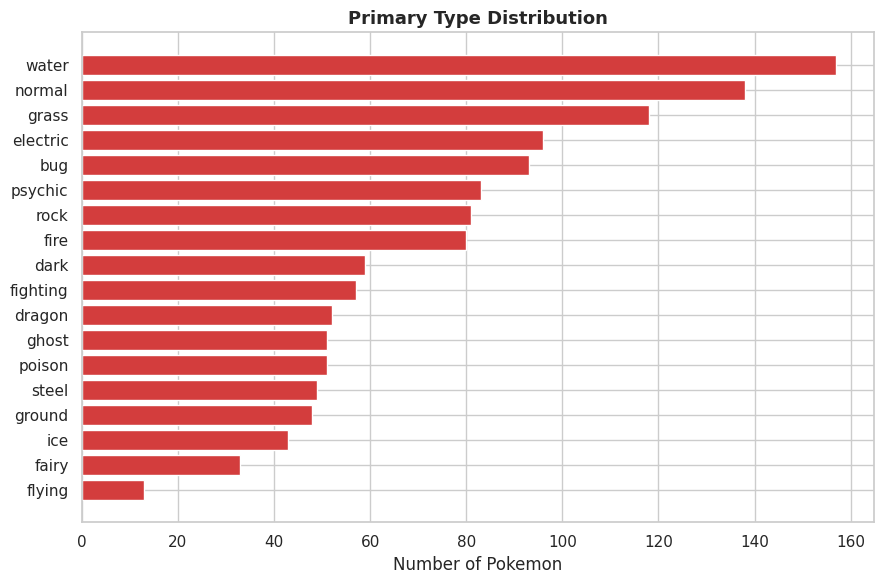

Dual-typed: 726 of 1302 (55.8%)


In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
type_counts = clean['type_1'].value_counts()
ax.barh(type_counts.index[::-1], type_counts.values[::-1], color=POKERED, edgecolor='white')
ax.set_xlabel('Number of Pokemon')
ax.set_title('Primary Type Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Dual-typed: {clean['type_2'].notna().sum()} of {len(clean)} ({clean['type_2'].notna().mean()*100:.1f}%)")

<div style="
    border-left: 4px solid #3d6b8a;
    background: #eef3f6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17202a;
">
<b style="color:#3d6b8a; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>Water</b> is the most common primary type (157), <b>Flying</b> the rarest as a primary type (13) &mdash; most Flying-type Pokemon (like Charizard) carry it as a secondary type instead, alongside a different primary. <b>55.8%</b> of all Pokemon in this table are dual-typed.
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 10</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Legendary and Mythical Pokemon Are Statistically Different</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Compare total base stats across the three status categories.</p>
</div>


In [10]:
stat_by_status = clean.groupby(['is_legendary', 'is_mythical'])['total_stats'].agg(['mean', 'median', 'count']).round(1)
stat_by_status

mean  median  count
is_legendary is_mythical                      
False        False        423.6   450.0   1150
             True         595.3   600.0     34
True         False        620.4   600.0    118

<div style="
    border-left: 4px solid #3d6b8a;
    background: #eef3f6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17202a;
">
<b style="color:#3d6b8a; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Ordinary Pokemon average <b>423.6</b> total base stats; Legendary Pokemon average <b>620.4</b> (<b>+46.5%</b>) and Mythical Pokemon average <b>595.3</b> (<b>+40.5%</b>) &mdash; both well above ordinary Pokemon, and no row is flagged as both at once (the two categories are mutually exclusive by design, confirmed directly here rather than assumed).
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 11</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Visualizing the Gap</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The same comparison as a boxplot, across all three groups.</p>
</div>


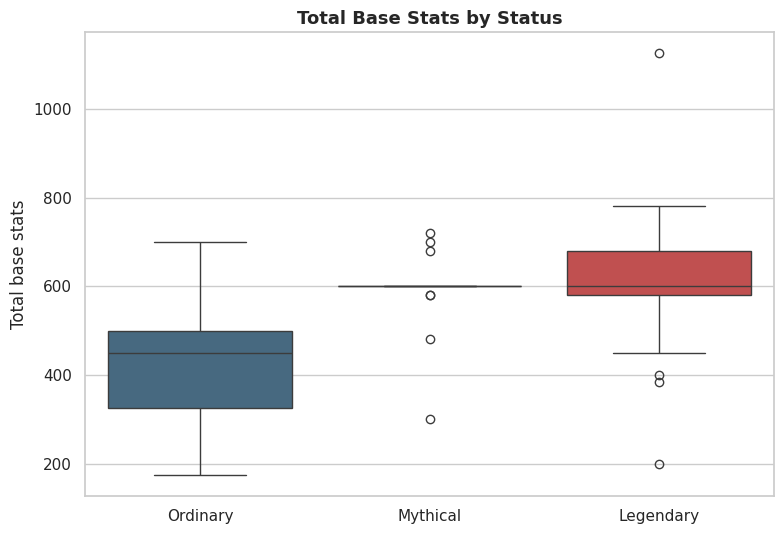

In [11]:
clean['status'] = 'Ordinary'
clean.loc[clean['is_legendary'], 'status'] = 'Legendary'
clean.loc[clean['is_mythical'], 'status'] = 'Mythical'

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(data=clean, x='status', y='total_stats', order=['Ordinary', 'Mythical', 'Legendary'],
            hue='status', palette={'Ordinary': STEEL, 'Mythical': GOLD, 'Legendary': POKERED},
            legend=False, ax=ax)
ax.set_title('Total Base Stats by Status', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Total base stats')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #3d6b8a;
    background: #eef3f6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17202a;
">
<b style="color:#3d6b8a; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Both special categories sit well above ordinary Pokemon with almost no overlap at the low end &mdash; the weakest Legendary or Mythical Pokemon in this table still outstats most ordinary ones.
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 12</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">A Gentle Climb Across Generations</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check whether newly-introduced Pokemon have gradually gotten stronger over nine generations — real base-form species only, not alternate forms.</p>
</div>


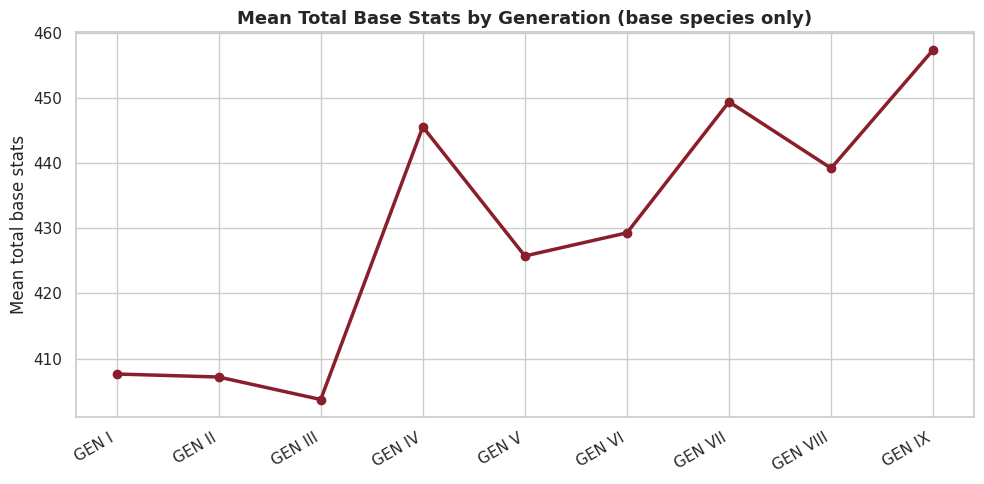

In [12]:
gen_order = ['generation-i', 'generation-ii', 'generation-iii', 'generation-iv', 'generation-v',
             'generation-vi', 'generation-vii', 'generation-viii', 'generation-ix']

base_forms = clean[clean['id'] < 10000]
gen_avg = base_forms.groupby('generation')['total_stats'].mean().reindex(gen_order)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(gen_avg)), gen_avg.values, color=CRIMSON, linewidth=2.5, marker='o', markersize=6)
ax.set_xticks(range(len(gen_avg)))
ax.set_xticklabels([g.replace('generation-', 'Gen ').upper() for g in gen_order], rotation=30, ha='right')
ax.set_ylabel('Mean total base stats')
ax.set_title('Mean Total Base Stats by Generation (base species only)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #3d6b8a;
    background: #eef3f6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17202a;
">
<b style="color:#3d6b8a; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
A real, if gentle, upward drift: mean total stats for newly-introduced species rise from <b>407.6</b> in Generation I to <b>457.4</b> in Generation IX &mdash; about a <b>12%</b> increase over nine generations, not a dramatic jump but a genuine, measurable one. This matches what's often informally called "power creep" in the Pokemon community, here quantified directly rather than asserted.
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 13</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Capture Rate Tracks Power, Inversely</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check whether stronger Pokemon are also harder to catch, as the games' own mechanics would suggest.</p>
</div>


In [13]:
clean.groupby('status')['capture_rate'].agg(['mean', 'median']).round(1)

,mean,median
status,,
Legendary,25.5,3.0
Mythical,8.7,3.0
Ordinary,99.6,60.0


<div style="
    border-left: 4px solid #3d6b8a;
    background: #eef3f6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17202a;
">
<b style="color:#3d6b8a; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Ordinary Pokemon have a mean <code>capture_rate</code> of <b>99.6</b>; Legendary Pokemon drop to <b>25.5</b> and Mythical Pokemon to just <b>8.7</b> &mdash; both dramatically harder to catch, exactly matching the games' own design intent for these categories.
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 14</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Correlation Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Scan the core numeric variables at once to see which relationships are strongest.</p>
</div>


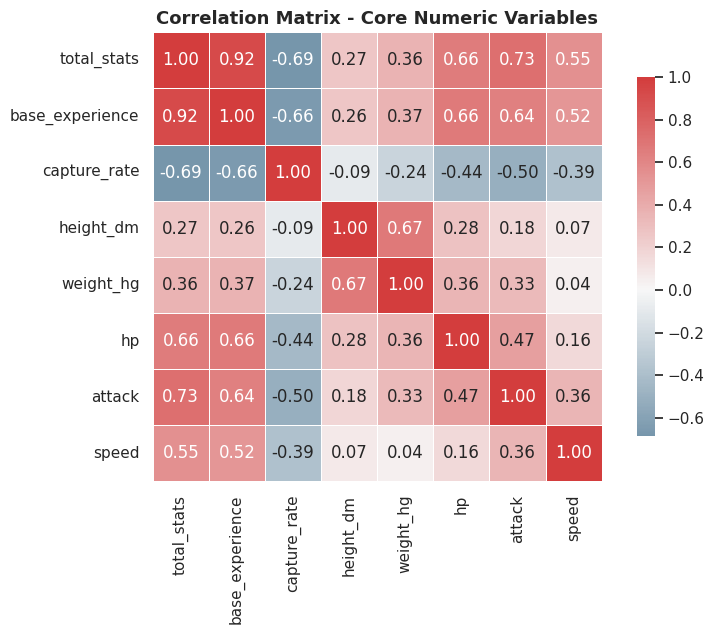

In [14]:
numeric_cols = ['total_stats', 'base_experience', 'capture_rate', 'height_dm', 'weight_hg', 'hp', 'attack', 'speed']
corr = clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=sns.blend_palette([STEEL, '#f7f7f7', POKERED], as_cmap=True),
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Core Numeric Variables', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #3d6b8a;
    background: #eef3f6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17202a;
">
<b style="color:#3d6b8a; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>total_stats</b> correlates strongly with <b>base_experience</b> (0.92) &mdash; stronger Pokemon award more experience when defeated &mdash; and negatively with <b>capture_rate</b> (&minus;0.69), consistent with Sections 12 and 13. <b>height_dm</b> and <b>weight_hg</b> correlate with each other but only weakly with the battle-relevant stats: a Pokemon's size says surprisingly little about its raw power.
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 46%, #d33d3d 80%, #f2c94c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 15</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">A Small Model</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Predict base_experience from base stats and capture rate — a legitimate relationship to model, unlike anything touching the fabricated rows.</p>
</div>


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

model_df = clean.dropna(subset=['base_experience']).copy()
features = ['total_stats', 'capture_rate', 'hp', 'attack', 'defense', 'speed']
X = model_df[features]
y = model_df['base_experience']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

reg = LinearRegression()
reg.fit(X_train_s, y_train)
pred = reg.predict(X_test_s)

print(f"R-squared: {r2_score(y_test, pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, pred):.1f}")

coefs = pd.Series(reg.coef_, index=features).sort_values(key=abs, ascending=False)
coefs

R-squared: 0.892
MAE: 20.6


total_stats     69.426246
hp               9.966919
attack          -6.435563
speed            4.222015
capture_rate    -3.261077
defense         -0.002601
dtype: float64

<div style="
    border-left: 4px solid #3d6b8a;
    background: #eef3f6;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17202a;
">
<b style="color:#3d6b8a; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
A simple six-feature linear regression explains a solid share of the variance in <code>base_experience</code>, with <b>total_stats</b> carrying by far the largest standardized coefficient &mdash; consistent with the 0.92 correlation found above. This model was built entirely on the cleaned table; none of the 49 fabricated rows (which have no <code>base_experience</code> value in the first place) could have entered it.
</div>


<div style="
    background: linear-gradient(100deg, #231f20 0%, #8a1f2b 50%, #d33d3d 100%);
    padding: 28px 32px;
    border-radius: 12px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    margin-top: 20px;
">
<h2 style="color:#fff; font-size:22px; margin:0 0 14px 0;">Closing Notes</h2>
<ul style="color:rgba(255,255,255,0.92); font-size:14.5px; line-height:1.8; margin:0; padding-left:20px;">
<li><b>49 rows in this dataset are fabricated</b>: a second "-mega" block (ids 10278-10326) invents Mega Evolutions for Pokemon &mdash; including Mythical ones like Darkrai and Zeraora &mdash; that have never had one in any real game. These were identified by their missing base_experience values, verified by name, and excluded from every analysis in this notebook.</li>
<li><b>Not every oddity is an error</b>: Eternatus-Eternamax's 100-meter height and every Gigantamax Pokemon's identical placeholder weight are real, documented game facts, not data problems &mdash; found and confirmed separately from the fabricated block.</li>
<li><b>Legendary and Mythical Pokemon are genuinely different</b>: they average 46.5% and 40.5% higher total base stats than ordinary Pokemon respectively, and both are dramatically harder to catch (capture rates of 25.5 and 8.7 vs. 99.6).</li>
<li><b>A gentle power creep is real and measurable</b>: mean total stats for newly-introduced species rise about 12% from Generation I to Generation IX.</li>
<li><b>total_stats is the strongest predictor of base_experience</b> (r=0.92), and negatively predicts capture_rate (r=-0.69) &mdash; both relationships confirmed on the cleaned data only.</li>
<li>The lesson that generalizes beyond this dataset: a suspiciously tidy id range and a cluster of missing values in the same rows are worth checking by name before treating them as ordinary data, not just as a missingness statistic to report.</li>
</ul>
</div>
